In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
save_dir = "../figure_data/figure_S_tree_mortality/"

years = np.load(os.path.join(save_dir, "years.npy"))
median_pct_loss = np.load(os.path.join(save_dir, "median_pct_loss.npy"))
all_burned_pct_losses_nonans = np.load(os.path.join(save_dir, "all_burned_pct_losses_nonans.npy"))
vals = xr.open_dataarray(os.path.join(save_dir, "vals.nc"))
fia_deltas_clean_mean = np.load(os.path.join(save_dir, "fia_deltas_clean_mean.npy"))[0]
fia_deltas_finite = np.load(os.path.join(save_dir, "fia_deltas_finite.npy"))

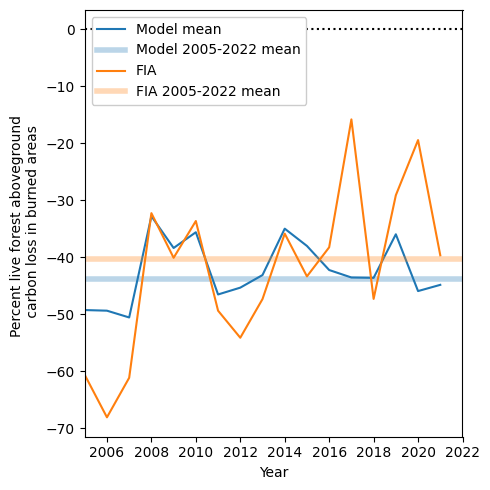

In [4]:
plt.figure(figsize=(5, 5))

# ── Time-series subplot ──────────────────────────────────────────────────────
plt.plot(years, median_pct_loss, label="Model mean")
plt.axhline(y=0, linestyle=":", color="k")
plt.axhline(
    y=np.mean(all_burned_pct_losses_nonans),
    linestyle="-",
    color="C0",
    linewidth=4,
    alpha=0.3,
    label="Model 2005-2022 mean",
)

vals.plot(color="C1", label="FIA")
plt.axhline(
    y=fia_deltas_clean_mean,
    linestyle="-",
    color="C1",
    linewidth=4,
    alpha=0.3,
    label="FIA 2005-2022 mean",
)

plt.ylabel("Percent live forest aboveground \n carbon loss in burned areas")
plt.xlabel("Year")
plt.legend(loc="upper left", framealpha=1)
plt.xlim([2005, 2022])

plt.savefig("Forest-mortality-comparison.pdf")
plt.tight_layout()